In [5]:
import wandb
import pandas as pd

api = wandb.Api()
runs = api.runs("wan-phase-experiments-2") 

records = []
for run in runs:
    history = run.history(keys=["mse_mag", "cosine_dist_mean"], pandas=True)
    records.append({
        "name": run.name,
        "mse_mag": history["mse_mag"].dropna().tolist(),
        "cosine_dist_mean": history["cosine_dist_mean"].dropna().tolist(),
    })

df = pd.DataFrame(records, columns=["name", "mse_mag", "cosine_dist_mean"])
#df.to_csv("../data/wandb_grid_search_results_experiments_4.csv", index=False)
df.head(5)

,name,mse_mag,cosine_dist_mean
0,face1_prompt_0_alpha_0.4,"[1866.721923828125, 1860.4052734375, 1801.3161...","[-0.00011737495515262708, -0.00015353712660726..."
1,face1_prompt_1_alpha_0.4,"[1870.4482421875, 1864.107421875, 1805.0013427...","[0.0004259374691173434, 0.0004122471436858177,..."
2,face1_prompt_2_alpha_0.4,"[1866.6907958984375, 1860.158447265625, 1801.4...","[0.0004498858761508018, 0.0004209201142657548,..."
3,face1_prompt_3_alpha_0.4,"[1872.31494140625, 1865.870849609375, 1806.803...","[-7.209918840089813e-05, -8.993761730380356e-0..."
4,face1_prompt_4_alpha_0.4,"[1868.5137939453125, 1862.0240478515625, 1803....","[-0.0006725389393977821, -0.000701570941600948..."


In [ ]:
import numpy as np
import ast

#df = pd.read_csv("../data/wandb_grid_search_results.csv")

#df["cosine_dist_mean"] = df["cosine_dist_mean"].apply(ast.literal_eval)
#df["mse_mag"] = df["mse_mag"].apply(ast.literal_eval)

good_videos = ["cat_prompt_1_alpha_0.4","cat_prompt_6_alpha_0.4","dog_prompt_6_alpha_0.4", "face1_prompt_1_alpha_0.4", "face1_prompt_6_alpha_0.4", "face2_prompt_0_alpha_0.4", "face2_prompt_6_alpha_0.4", "skull_prompt_1_alpha_0.4", "skull_prompt_6_alpha_0.4" ]
#good videos experiment 4
#good_videos = ["cat_prompt_1_alpha_0.4","dog_prompt_6_alpha_0.4", "face1_prompt_1_alpha_0.4", "face1_prompt_6_alpha_0.4", "face2_prompt_0_alpha_0.4", "face2_prompt_1_alpha_0.4", "face2_prompt_2_alpha_0.4", "skull_prompt_0_alpha_0.4", "skull_prompt_1_alpha_0.4", "skull_prompt_6_alpha_0.4" ]

df_good = df[df["name"].isin(good_videos)].copy()
df_rest = df[~df["name"].isin(good_videos)].copy()

good_cos_arrays = np.array(df_good["cosine_dist_mean"].tolist())
rest_cos_arrays = np.array(df_rest["cosine_dist_mean"].tolist())
good_mse_arrays = np.array(df_good["mse_mag"].tolist())
rest_mse_arrays = np.array(df_rest["mse_mag"].tolist())

#Mean and variance for each phase path
good_average_phase_path = good_cos_arrays.mean(axis=0).tolist()
good_variance_phase_path = good_cos_arrays.var(axis=0).tolist()
rest_average_phase_path = rest_cos_arrays.mean(axis=0).tolist()
rest_variance_phase_path = rest_cos_arrays.var(axis=0).tolist()

#Mean and variance for each magnitude path
good_average_mse_path = good_mse_arrays.mean(axis=0).tolist()
good_variance_mse_path = good_mse_arrays.var(axis=0).tolist()
rest_average_mse_path = rest_mse_arrays.mean(axis=0).tolist()
rest_variance_mse_path = rest_mse_arrays.var(axis=0).tolist()

print(len(good_average_phase_path), len(good_variance_phase_path), len(rest_average_phase_path), len(rest_variance_phase_path))
print(len(good_average_mse_path), len(good_variance_mse_path), len(rest_average_mse_path), len(rest_variance_mse_path))

101 101 101 101
101 101 101 101


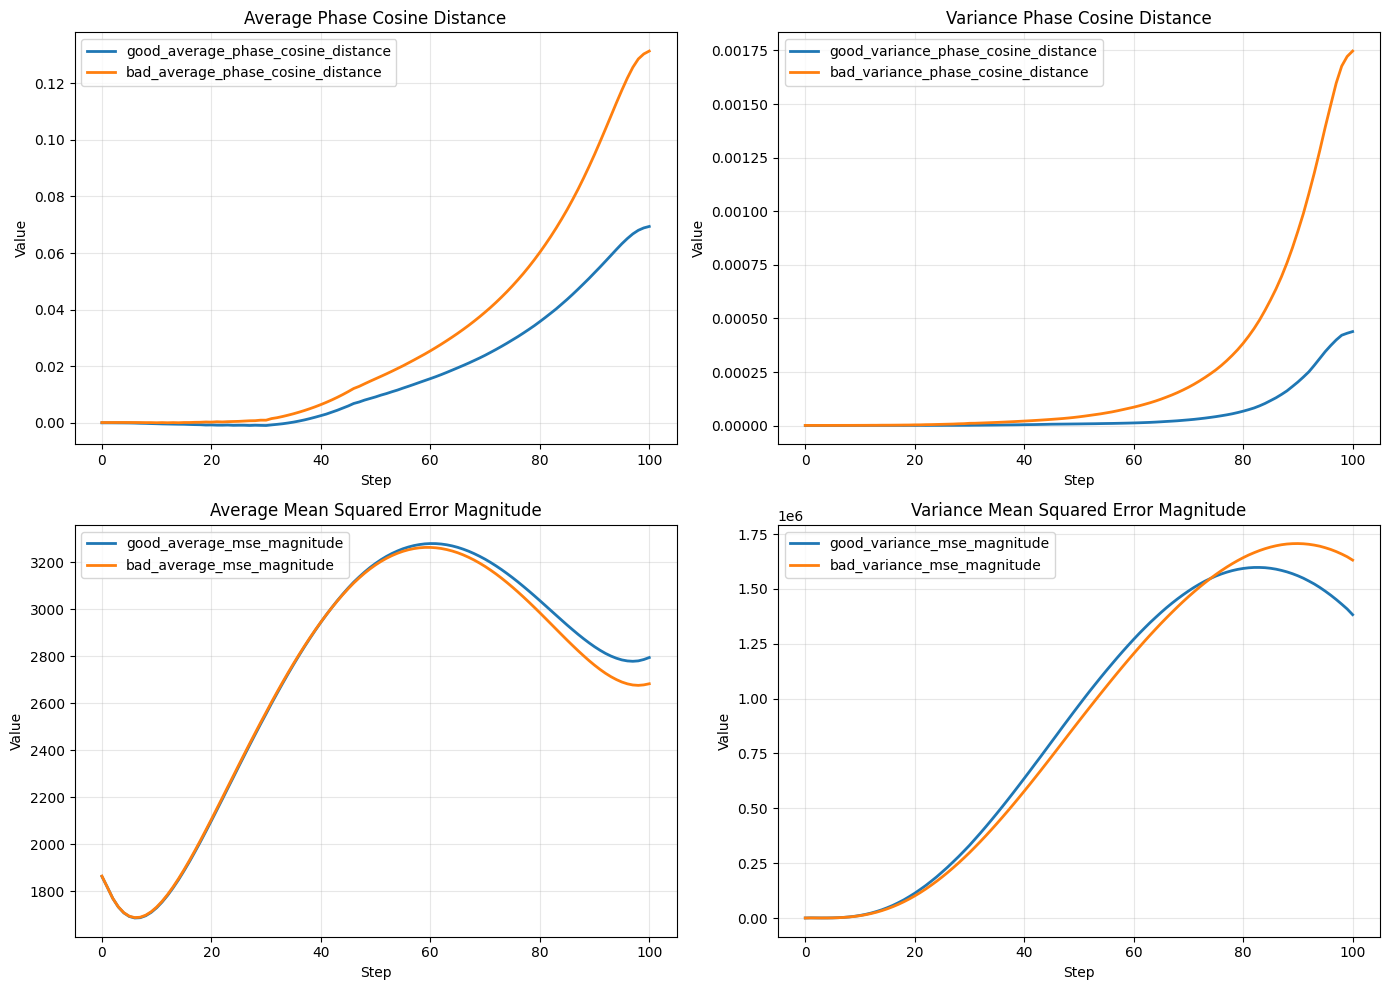

Good average phase path: [-6.200985495120726e-05, -6.058187369085822e-05, -6.761343396040805e-05, -8.138445223772174e-05, -9.184296141029336e-05, -0.00011160417206055071, -0.0001505684906280496, -0.00021790540712471638, -0.0002567171569454432, -0.00032562888494188275, -0.0003826023651830231, -0.00044208285382612504, -0.0004843957564541294, -0.0005205544217056336, -0.0005632622099559134, -0.0005802941660577846, -0.0006478026350830785, -0.0006998935779039231, -0.0007360325835179538, -0.0008440101713252565, -0.0008136954226453478, -0.0008889260388968978, -0.0009020700947278076, -0.0008493447191237161, -0.0009512057723542158, -0.0009169226428235157, -0.0009235517354682088, -0.00099472692495005, -0.0009173625084157619, -0.0009695586231828202, -0.0010059405111759487, -0.000792944722989988, -0.0006002486031017421, -0.0003896193261930926, -0.00012020914517860446, 0.000189810626680911, 0.0005618012038818657, 0.0009686094935103837, 0.0014392057734463985, 0.0019440547928550383, 0.0024831731861922

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: average phase path
axes[0, 0].plot(good_average_phase_path, label="good_average_phase_cosine_distance", linewidth=2)
axes[0, 0].plot(rest_average_phase_path, label="bad_average_phase_cosine_distance", linewidth=2)
axes[0, 0].set_title("Average Phase Cosine Distance")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Value")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: variance phase path
axes[0, 1].plot(good_variance_phase_path, label="good_variance_phase_cosine_distance", linewidth=2)
axes[0, 1].plot(rest_variance_phase_path, label="bad_variance_phase_cosine_distance", linewidth=2)
axes[0, 1].set_title("Variance Phase Cosine Distance")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Value")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: average mse path
axes[1, 0].plot(good_average_mse_path, label="good_average_mse_magnitude", linewidth=2)
axes[1, 0].plot(rest_average_mse_path, label="bad_average_mse_magnitude", linewidth=2)
axes[1, 0].set_title("Average Mean Squared Error Magnitude")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Value")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: variance mse path
axes[1, 1].plot(good_variance_mse_path, label="good_variance_mse_magnitude", linewidth=2)
axes[1, 1].plot(rest_variance_mse_path, label="bad_variance_mse_magnitude", linewidth=2)
axes[1, 1].set_title("Variance Mean Squared Error Magnitude")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Value")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Good average phase path:", good_average_phase_path)
print("Rest average phase path:", rest_average_phase_path)

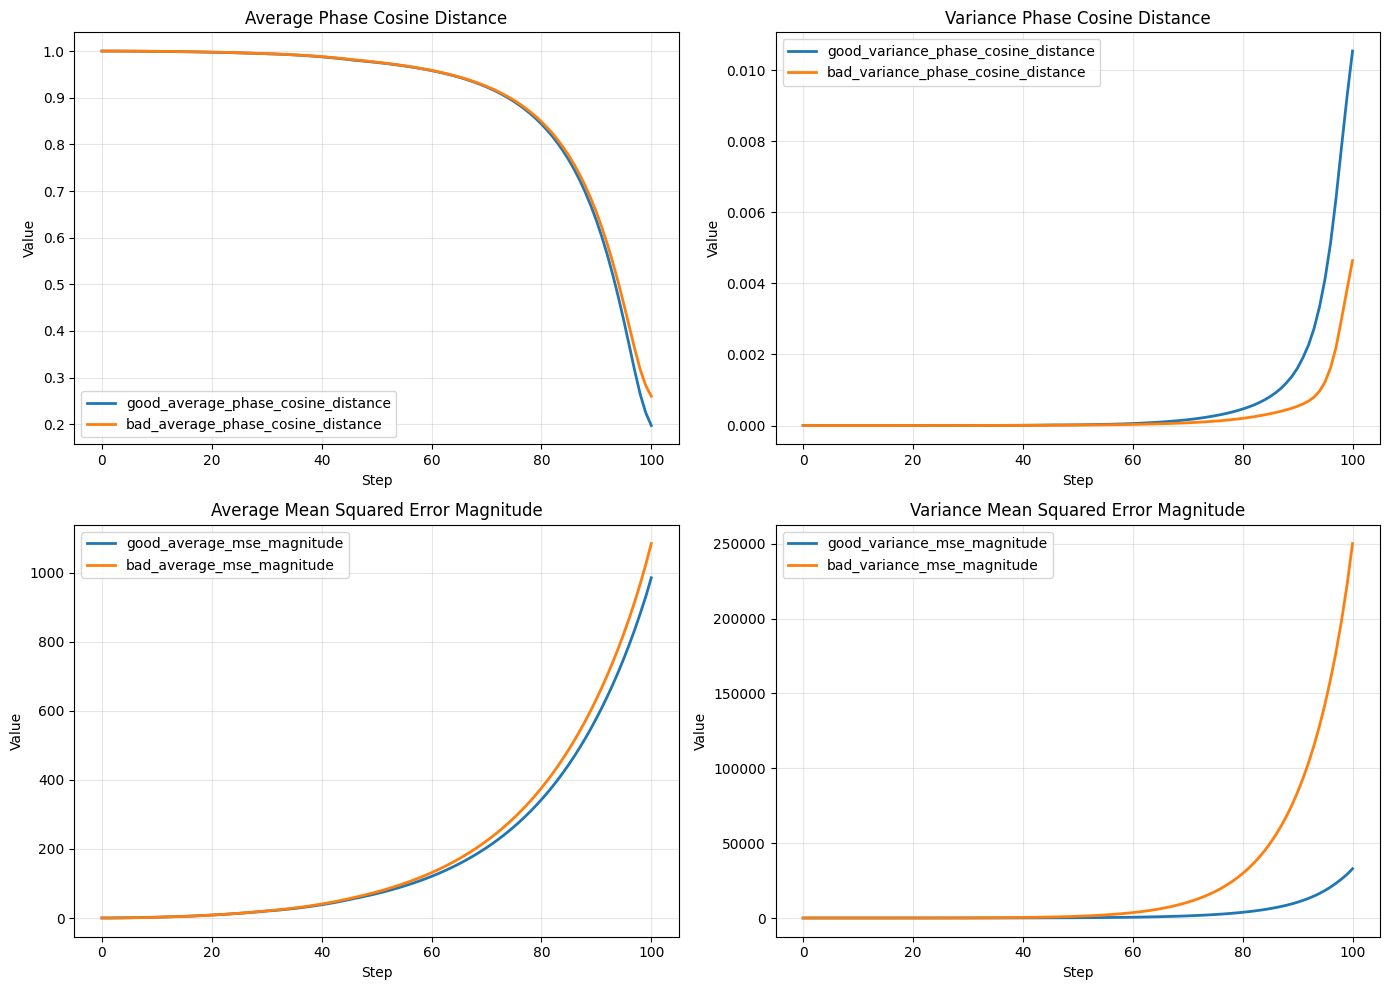

Good average mse path: [0.23949788101017475, 0.1369719620794058, 0.2994705930352211, 0.4489714190363884, 0.6527794733643532, 0.8707191795110703, 1.1416972398757934, 1.45402392745018, 1.7538035452365874, 2.161292850971222, 2.506959068775177, 2.990635669231415, 3.3466163873672485, 3.904379105567932, 4.340088987350464, 4.983134126663208, 5.557680201530457, 6.281952834129333, 7.00006844997406, 7.825699996948242, 8.632620286941528, 9.54858856201172, 10.46096887588501, 11.447629022598267, 12.585383129119872, 13.61175832748413, 14.901562118530274, 15.99980640411377, 17.381387519836426, 18.72772331237793, 20.240311527252196, 21.286604785919188, 22.747885704040527, 24.281941223144532, 25.928246116638185, 27.670311546325685, 29.560901832580566, 31.59542770385742, 33.75687599182129, 36.04352378845215, 38.54211254119873, 41.11324615478516, 43.9001049041748, 46.82794666290283, 49.98893814086914, 53.29274063110351, 56.87168159484863, 59.863982391357425, 63.3687931060791, 66.9205753326416, 70.6350452

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: average phase path
axes[0, 0].plot(good_average_phase_path, label="good_average_phase_cosine_distance", linewidth=2)
axes[0, 0].plot(rest_average_phase_path, label="bad_average_phase_cosine_distance", linewidth=2)
axes[0, 0].set_title("Average Phase Cosine Distance")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Value")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: variance phase path
axes[0, 1].plot(good_variance_phase_path, label="good_variance_phase_cosine_distance", linewidth=2)
axes[0, 1].plot(rest_variance_phase_path, label="bad_variance_phase_cosine_distance", linewidth=2)
axes[0, 1].set_title("Variance Phase Cosine Distance")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Value")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: average mse path
axes[1, 0].plot(good_average_mse_path, label="good_average_mse_magnitude", linewidth=2)
axes[1, 0].plot(rest_average_mse_path, label="bad_average_mse_magnitude", linewidth=2)
axes[1, 0].set_title("Average Mean Squared Error Magnitude")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Value")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: variance mse path
axes[1, 1].plot(good_variance_mse_path, label="good_variance_mse_magnitude", linewidth=2)
axes[1, 1].plot(rest_variance_mse_path, label="bad_variance_mse_magnitude", linewidth=2)
axes[1, 1].set_title("Variance Mean Squared Error Magnitude")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Value")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Good average mse path:", good_average_mse_path)
print("Rest average mse path:", rest_average_mse_path)

# Heuristic analysis


In [1]:
import wandb
import pandas as pd

api = wandb.Api()
runs = api.runs("wan-heuristic-experiments-1") 

records = []
for run in runs:
    history = run.history(keys=["cond_mse_mag", "ref_cosine_dist_mean"], pandas=True)
    records.append({
        "name": run.name,
        "cond_mse_mag": history["cond_mse_mag"].dropna().tolist(),
        "ref_cosine_dist_mean": history["ref_cosine_dist_mean"].dropna().tolist(),
    })

df = pd.DataFrame(records, columns=["name", "cond_mse_mag", "ref_cosine_dist_mean"])
df.to_csv("../data/wandb_grid_search_results_heuristic_1.csv", index=False)
df.head(5)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/s2710099/.netrc.


,name,cond_mse_mag,ref_cosine_dist_mean
0,face1_ref_cos_threshold_0.03_ref_factor_0.01_c...,"[0.0, 0.014044525101780891, 0.0402252636849880...","[-0.0017234404804185033, -0.001799721154384315..."
1,face1_ref_cos_threshold_0.05_ref_factor_0.01_c...,"[0.0, 0.024433467537164688, 0.0789777711033821...","[-1.2615112609637436e-05, -7.26820362615399e-0..."
2,face1_ref_cos_threshold_0.05_ref_factor_0.01_c...,"[0.0, 0.013029821217060089, 0.0350751765072345...","[0.0018308574799448252, 0.0017481112154200673,..."
3,face1_ref_cos_threshold_0.03_ref_factor_0.01_c...,"[0.0, 0.016768556088209152, 0.0496956966817379...","[0.0006606884999200702, 0.0005639021983370185,..."
4,face1_ref_cos_threshold_0.05_ref_factor_0.01_c...,"[0.0, 0.013820147141814232, 0.0386860594153404...","[-0.001080598565749824, -0.0012078649597242475..."


In [2]:
import ast
import re

# If needed after reloading from csv:
# df = pd.read_csv("../data/wandb_grid_search_results_heuristic_1.csv")
# df["cond_mse_mag"] = df["cond_mse_mag"].apply(ast.literal_eval)
# df["ref_cosine_dist_mean"] = df["ref_cosine_dist_mean"].apply(ast.literal_eval)

list_of_runs = [
    "face1_ref_cos_threshold_0.04_ref_factor_0.1_cond_mag_threshold_500_cond_factor_0.1",
    "face1_ref_cos_threshold_0.04_ref_factor_0.1_cond_mag_threshold_500_cond_factor_0.05",
    "face1_ref_cos_threshold_0.04_ref_factor_0.1_cond_mag_threshold_500_cond_factor_0.01",
    "face1_ref_cos_threshold_0.04_ref_factor_0.1_cond_mag_threshold_400_cond_factor_0.1",
    "face1_ref_cos_threshold_0.04_ref_factor_0.1_cond_mag_threshold_400_cond_factor_0.05",
    "face1_ref_cos_threshold_0.04_ref_factor_0.1_cond_mag_threshold_400_cond_factor_0.01",
    "face1_ref_cos_threshold_0.04_ref_factor_0.05_cond_mag_threshold_500_cond_factor_0.1",
    "face1_ref_cos_threshold_0.04_ref_factor_0.05_cond_mag_threshold_500_cond_factor_0.05",
    "face1_ref_cos_threshold_0.04_ref_factor_0.05_cond_mag_threshold_500_cond_factor_0.01",
    "face1_ref_cos_threshold_0.04_ref_factor_0.05_cond_mag_threshold_400_cond_factor_0.1",
]


def parse_run_name(run_name):
    ref_threshold = float(re.search(r"ref_cos_threshold_([0-9.]+)", run_name).group(1))
    ref_factor = float(re.search(r"ref_factor_([0-9.]+)", run_name).group(1))
    cond_threshold = float(re.search(r"cond_mag_threshold_([0-9.]+)", run_name).group(1))
    cond_factor = float(re.search(r"cond_factor_([0-9.]+)", run_name).group(1))

    return {
        "ref_threshold": ref_threshold,
        "ref_factor": ref_factor,
        "cond_threshold": cond_threshold,
        "cond_factor": cond_factor,
    }


def compute_alpha_list(cond_mse_values, ref_cos_values, params, base_alpha=0.4):
    alphas = []

    for cond_mse_mag, ref_cosine_dist in zip(cond_mse_values, ref_cos_values):
        alpha = base_alpha

        if params["ref_threshold"] and ref_cosine_dist >= params["ref_threshold"]:
            alpha -= params["ref_factor"]

        if params["cond_threshold"] and cond_mse_mag < params["cond_threshold"]:
            alpha += params["cond_factor"]

        alphas.append(alpha)

    return alphas


selected_df = df[df["name"].isin(list_of_runs)].copy()
selected_df = selected_df.set_index("name").loc[list_of_runs].reset_index()

alpha_lists = []
alpha_by_run = {}

for _, row in selected_df.iterrows():
    run_name = row["name"]
    params = parse_run_name(run_name)

    alpha_values = compute_alpha_list(
        row["cond_mse_mag"],
        row["ref_cosine_dist_mean"],
        params,
        base_alpha=0.4,
    )

    if len(alpha_values) != 101:
        raise ValueError(f"Run {run_name} has {len(alpha_values)} values instead of 101")

    alpha_lists.append(alpha_values)
    alpha_by_run[run_name] = alpha_values

print(f"number of runs: {len(alpha_lists)}")
print(f"values per run: {[len(x) for x in alpha_lists]}")

# alpha_lists is the requested output: 10 lists, each containing 101 alpha values
alpha_lists


number of runs: 10
values per run: [101, 101, 101, 101, 101, 101, 101, 101, 101, 101]


[[0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4,
  0.4],
 [0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.45,
  0.

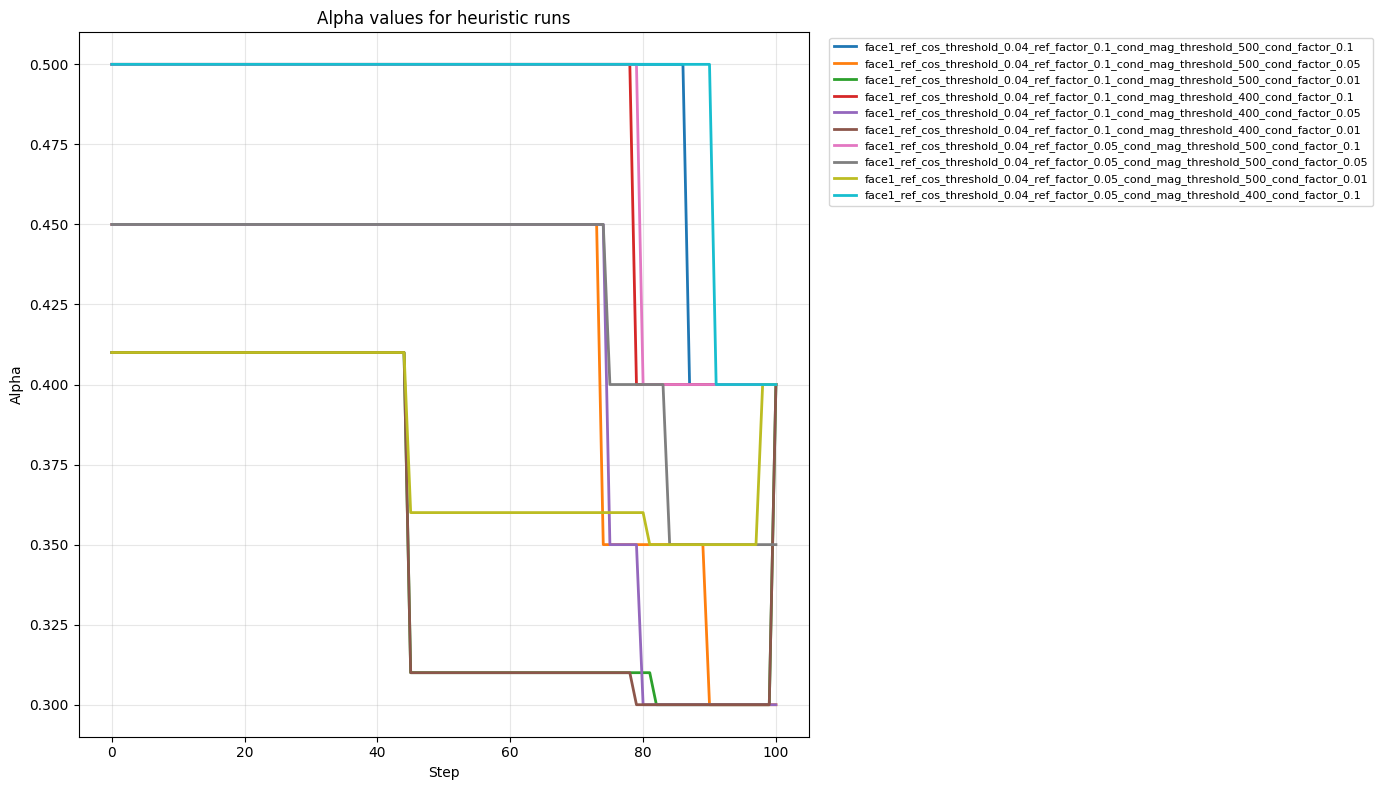

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(alpha_lists)))

for i, (run_name, alpha_values) in enumerate(zip(list_of_runs, alpha_lists)):
    plt.plot(
        range(len(alpha_values)),
        alpha_values,
        label=run_name,
        color=colors[i],
        linewidth=2,
    )

plt.title("Alpha values for heuristic runs")
plt.xlabel("Step")
plt.ylabel("Alpha")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

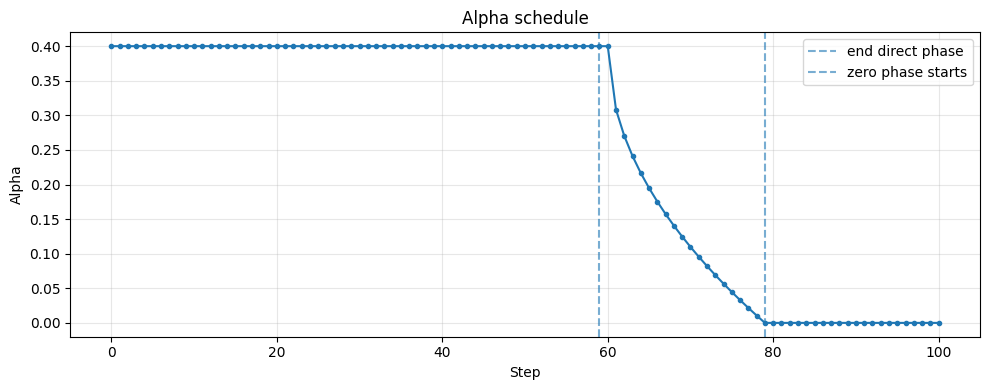

In [4]:
import matplotlib.pyplot as plt

initial_alpha = 0.4
num_steps = 101
direct_transfer_steps = 60
decayed_transfer_steps = 20
exponent = 0.5

alphas = []
for i in range(num_steps):
    if i < direct_transfer_steps:
        alpha = initial_alpha
    elif i < (direct_transfer_steps + decayed_transfer_steps - 1):
        decay_progress = (i - direct_transfer_steps) / max(decayed_transfer_steps - 1, 1)
        alpha = initial_alpha * (1 - decay_progress ** exponent)
    else:
        alpha = 0.0
    alphas.append(alpha)

plt.figure(figsize=(10, 4))
plt.plot(range(num_steps), alphas, marker='o', markersize=3)
plt.axvline(direct_transfer_steps - 1, linestyle='--', alpha=0.6, label='end direct phase')
plt.axvline(direct_transfer_steps + decayed_transfer_steps - 1, linestyle='--', alpha=0.6, label='zero phase starts')
plt.xlabel('Step')
plt.ylabel('Alpha')
plt.title('Alpha schedule')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
import wandb
import pandas as pd
import numpy as np

api = wandb.Api()
runs = api.runs("wan-heuristic-experiments-3") 

expected_steps = 101

records = []
for run in runs:
    history = run.history(keys=["cond_mse_mag", "ref_cosine_dist_mean", "alpha"], pandas=True)
    cosine = history["ref_cosine_dist_mean"].dropna().tolist()
    mse    = history["cond_mse_mag"].dropna().tolist()
    alpha  = history["alpha"].dropna().tolist()

    if len(cosine) != expected_steps:   # skip incomplete runs
        print(f"Skipping {run.name}: only {len(cosine)} steps")
        continue

    records.append({"name": run.name, "cond_mse_mag": mse,
                    "ref_cosine_dist_mean": cosine, "alpha": alpha})

df = pd.DataFrame(records, columns=["name", "cond_mse_mag", "ref_cosine_dist_mean", "alpha"])
#df.to_csv("../data/wandb_grid_search_results_heuristic_1.csv", index=False)
df.head(5)

cosine_array = np.array(df["ref_cosine_dist_mean"].tolist())
mse_array = np.array(df["cond_mse_mag"].tolist())
alpha_array = np.array(df["alpha"].tolist())

average_cosine = cosine_array.mean(axis=0).tolist()
average_mse = mse_array.mean(axis=0).tolist()
average_alpha = alpha_array.mean(axis=0).tolist()

print("Average cosine distance:", average_cosine)
print("Average MSE:", average_mse)
print("Average alpha:", average_alpha)


Skipping cat_prompt7: only 44 steps
Average cosine distance: [-0.00048592078162597096, -0.0005523106854966362, -0.0005718314725637549, -0.0006057575149249963, -0.0006194597120735456, -0.0006300817749985126, -0.0006243014400807266, -0.000602490818313196, -0.0005578306800364799, -0.0004823521704758715, -0.0003889223929339399, -0.0002981705095435521, -0.00019104293394114146, -5.2747981416442514e-05, 0.00010182594908683589, 0.0002659878527717383, 0.00045253146637343997, 0.0006724126023155721, 0.0009061525744266074, 0.0011473231918926379, 0.001404074848323944, 0.0016831947503505669, 0.0019659160549935855, 0.0022951543402141947, 0.002656467724922219, 0.0030292380534140675, 0.0034248779555844412, 0.0038563411190724846, 0.004308439242639438, 0.004801846126969339, 0.005324738523499532, 0.006037717939100482, 0.006675395924089985, 0.0073883240252281684, 0.00813734798099507, 0.008932963098314676, 0.009774940497608799, 0.010669999092704418, 0.011629898552641724, 0.012649929306159416, 0.013730578322